# Stage 2 — Evaluation: Neural Baker vs Baselines

Cross-compares performance across evaluation runs:
- `neural_baker` — LODThresholdPredictor active, SetLODs() per frame
- `fixed_default` — Unity default LOD thresholds, neural off
- `fixed_aggressive` — halved LOD thresholds, neural off

Metrics: mean/P95/P99 CPU ms, GPU ms, FPS, inference overhead, LOD flip rate, predicted threshold distribution.

In [49]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded OK')

Libraries loaded OK


## 1. Configuration

Point `EVAL_DIR` at the folder containing your `inference_eval_*.csv` files.
All CSVs in that folder will be loaded and grouped by `run_label`.

In [50]:
# path to folder containing inference_eval_*.csv files
BASE_DIR = Path('../..').resolve()  # ml_pipeline/
EVAL_DIR = BASE_DIR / 'data' / 'Baker_Eval_2'
BASELINE_DIR = BASE_DIR / 'data' / 'BaseLine'
PLOTS_DIR = BASE_DIR / 'plots' / 'Stage_2_2' / 'Eval'

print(f'Data dir:  {BASE_DIR}')
print(f'EVAL_DIR dir: {EVAL_DIR}')
print(f'BASELINE_DIR dir: {BASELINE_DIR}')
print(f'PLOTS_DIR dir: {PLOTS_DIR}')

# target frame budget in ms for budget line on plots
FRAME_BUDGET_MS = 16.67  # 60 FPS target

# run label colors for plots
RUN_COLORS = {
    'neural_baker':    '#2196F3',
    'fixed_default':   '#4CAF50',
    'fixed_aggressive':'#FF9800',
}
DEFAULT_COLOR = '#9C27B0'

print(f'Eval dir: {EVAL_DIR.resolve()}')

Data dir:  C:\Users\Gica\neural-lod\ml_pipeline
EVAL_DIR dir: C:\Users\Gica\neural-lod\ml_pipeline\data\Baker_Eval_2
BASELINE_DIR dir: C:\Users\Gica\neural-lod\ml_pipeline\data\BaseLine
PLOTS_DIR dir: C:\Users\Gica\neural-lod\ml_pipeline\plots\Stage_2_2\Eval
Eval dir: C:\Users\Gica\neural-lod\ml_pipeline\data\Baker_Eval_2


## 2. Load All Eval CSVs

In [51]:
csv_files = list(EVAL_DIR.glob('inference_eval_*.csv')) + list(BASELINE_DIR.glob('inference_eval_*.csv'))
print(f'Found {len(csv_files)} eval CSVs:')
for f in csv_files:
    print(f'  {f.name}')

if len(csv_files) == 0:
    raise FileNotFoundError(f'No inference_eval_*.csv files found in {EVAL_DIR.resolve()}')

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    # skip comment lines if any
    df = df[~df['run_label'].astype(str).str.startswith('#')]
    df['source_file'] = f.name
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# cast numeric columns
numeric_cols = ['frame','cpu_ms','gpu_ms','fps','inference_duration_ms','predicted_threshold','lod_bias_applied']
for col in numeric_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna(subset=['cpu_ms','gpu_ms','fps'])

runs = sorted(data['run_label'].unique())
print(f'\nRun labels found: {runs}')
print(f'Total rows: {len(data):,}')
print()
print(data.groupby('run_label').size().rename('rows'))

Found 3 eval CSVs:
  inference_eval_neural_baker_20260402_160223.csv
  inference_eval_fixed_aggressive_20260402_151308.csv
  inference_eval_fixed_default_20260402_151150.csv

Run labels found: ['fixed_aggressive', 'fixed_default', 'neural_baker']
Total rows: 13,419

run_label
fixed_aggressive    4225
fixed_default       3914
neural_baker        5280
Name: rows, dtype: int64


## 3. Summary Statistics

In [52]:
def percentile(series, p):
    return float(np.percentile(series.dropna(), p))

summary_rows = []

for run in runs:
    df = data[data['run_label'] == run]
    cpu = df['cpu_ms']
    gpu = df['gpu_ms']
    fps = df['fps']
    inf = df['inference_duration_ms'] if 'inference_duration_ms' in df.columns else pd.Series([0])
    thr = df['predicted_threshold'] if 'predicted_threshold' in df.columns else pd.Series([0])
    lod = df['lod_bias_applied'] if 'lod_bias_applied' in df.columns else pd.Series([1])

    # LOD flip rate
    lod_vals = lod.values
    switches = sum(1 for i in range(1, len(lod_vals)) if abs(lod_vals[i] - lod_vals[i-1]) > 0.001)
    duration_s = len(df) / fps.mean() if fps.mean() > 0 else 1
    flip_rate = switches / duration_s if duration_s > 0 else 0

    # frames over budget
    over_budget_pct = 100 * (cpu > FRAME_BUDGET_MS).sum() / len(cpu)

    summary_rows.append({
        'run_label':         run,
        'frames':            len(df),
        'mean_cpu_ms':       round(cpu.mean(), 3),
        'p95_cpu_ms':        round(percentile(cpu, 95), 3),
        'p99_cpu_ms':        round(percentile(cpu, 99), 3),
        'mean_gpu_ms':       round(gpu.mean(), 3),
        'p95_gpu_ms':        round(percentile(gpu, 95), 3),
        'p99_gpu_ms':        round(percentile(gpu, 99), 3),
        'mean_fps':          round(fps.mean(), 2),
        'p5_fps':            round(percentile(fps, 5), 2),
        'mean_inference_ms': round(inf.mean(), 4),
        'mean_threshold':    round(thr.mean(), 4),
        'lod_switches':      switches,
        'flip_rate_per_s':   round(flip_rate, 3),
        'over_budget_pct':   round(over_budget_pct, 1),
    })

summary = pd.DataFrame(summary_rows).set_index('run_label')
print('=== Summary Statistics ===')
print(summary.T.to_string())

=== Summary Statistics ===
run_label          fixed_aggressive  fixed_default  neural_baker
frames                     4225.000       3914.000     5280.0000
mean_cpu_ms                  16.666         16.666       11.9650
p95_cpu_ms                   17.032         17.048       17.8230
p99_cpu_ms                   17.250         17.390       18.3740
mean_gpu_ms                   4.683          5.218        5.3060
p95_gpu_ms                    5.657          6.402        7.0550
p99_gpu_ms                    6.021          6.761        7.3140
mean_fps                     60.000         60.000      100.8800
p5_fps                       59.740         59.730       55.0000
mean_inference_ms             0.000          0.000        0.1778
mean_threshold                0.000          0.000        0.2497
lod_switches                  0.000          0.000        0.0000
flip_rate_per_s               0.000          0.000        0.0000
over_budget_pct              49.100         49.800       22.300

## 4. CPU Frame Time Comparison

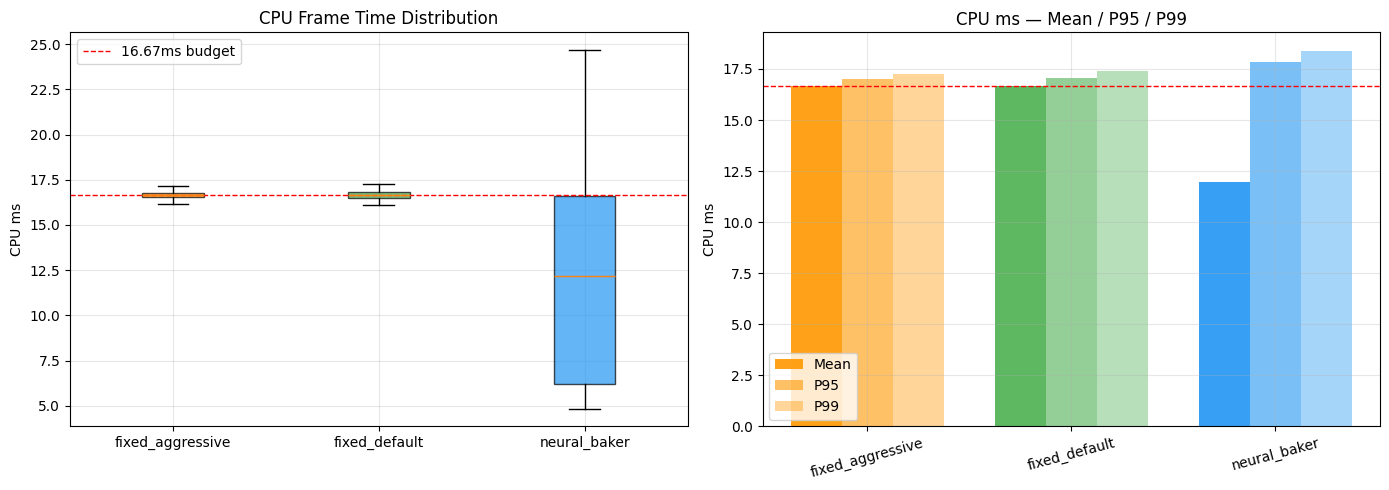

Saved: eval_cpu_comparison.png


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# box plot
ax = axes[0]
cpu_data = [data[data['run_label'] == r]['cpu_ms'].dropna().values for r in runs]
bp = ax.boxplot(cpu_data, labels=runs, patch_artist=True, showfliers=False)
for patch, run in zip(bp['boxes'], runs):
    patch.set_facecolor(RUN_COLORS.get(run, DEFAULT_COLOR))
    patch.set_alpha(0.7)
ax.axhline(FRAME_BUDGET_MS, color='red', linestyle='--', linewidth=1, label=f'{FRAME_BUDGET_MS}ms budget')
ax.set_title('CPU Frame Time Distribution')
ax.set_ylabel('CPU ms')
ax.legend()
ax.grid(True, alpha=0.3)

# mean + P95 + P99 bar chart
ax = axes[1]
x = np.arange(len(runs))
w = 0.25
means = [summary.loc[r, 'mean_cpu_ms'] for r in runs]
p95s  = [summary.loc[r, 'p95_cpu_ms']  for r in runs]
p99s  = [summary.loc[r, 'p99_cpu_ms']  for r in runs]
ax.bar(x - w, means, w, label='Mean',  color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.9)
ax.bar(x,     p95s,  w, label='P95',   color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.6)
ax.bar(x + w, p99s,  w, label='P99',   color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(runs, rotation=15)
ax.axhline(FRAME_BUDGET_MS, color='red', linestyle='--', linewidth=1)
ax.set_title('CPU ms — Mean / P95 / P99')
ax.set_ylabel('CPU ms')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eval_cpu_comparison.png', dpi=150)
plt.show()
print('Saved: eval_cpu_comparison.png')

## 5. GPU Frame Time Comparison

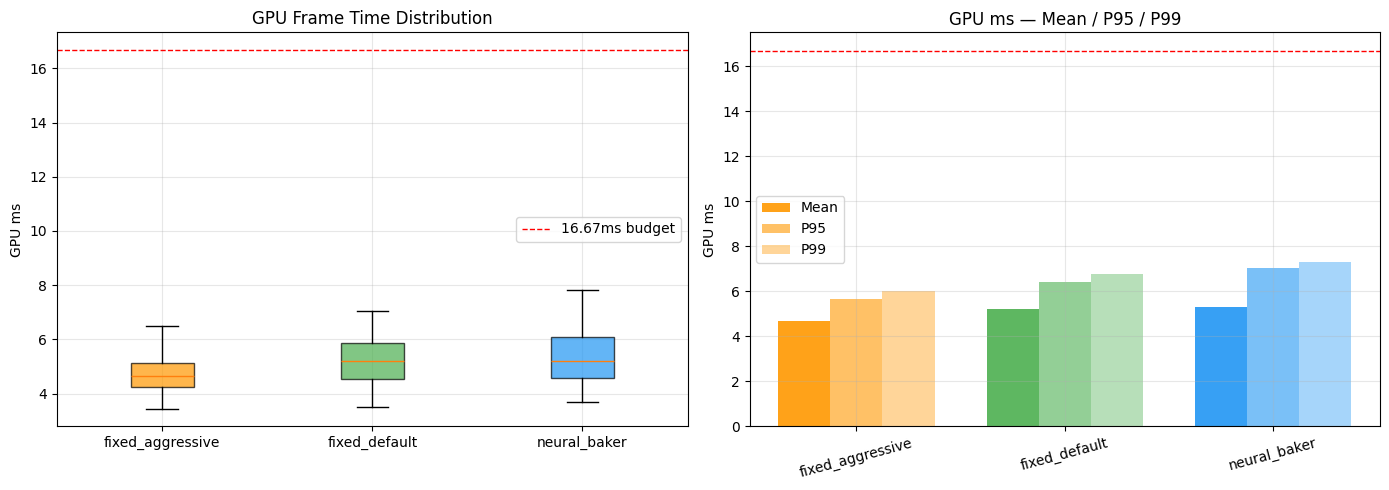

Saved: eval_gpu_comparison.png


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
gpu_data = [data[data['run_label'] == r]['gpu_ms'].dropna().values for r in runs]
bp = ax.boxplot(gpu_data, labels=runs, patch_artist=True, showfliers=False)
for patch, run in zip(bp['boxes'], runs):
    patch.set_facecolor(RUN_COLORS.get(run, DEFAULT_COLOR))
    patch.set_alpha(0.7)
ax.axhline(FRAME_BUDGET_MS, color='red', linestyle='--', linewidth=1, label=f'{FRAME_BUDGET_MS}ms budget')
ax.set_title('GPU Frame Time Distribution')
ax.set_ylabel('GPU ms')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
means = [summary.loc[r, 'mean_gpu_ms'] for r in runs]
p95s  = [summary.loc[r, 'p95_gpu_ms']  for r in runs]
p99s  = [summary.loc[r, 'p99_gpu_ms']  for r in runs]
ax.bar(x - w, means, w, label='Mean', color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.9)
ax.bar(x,     p95s,  w, label='P95',  color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.6)
ax.bar(x + w, p99s,  w, label='P99',  color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(runs, rotation=15)
ax.axhline(FRAME_BUDGET_MS, color='red', linestyle='--', linewidth=1)
ax.set_title('GPU ms — Mean / P95 / P99')
ax.set_ylabel('GPU ms')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eval_gpu_comparison.png', dpi=150)
plt.show()
print('Saved: eval_gpu_comparison.png')

## 6. FPS Comparison

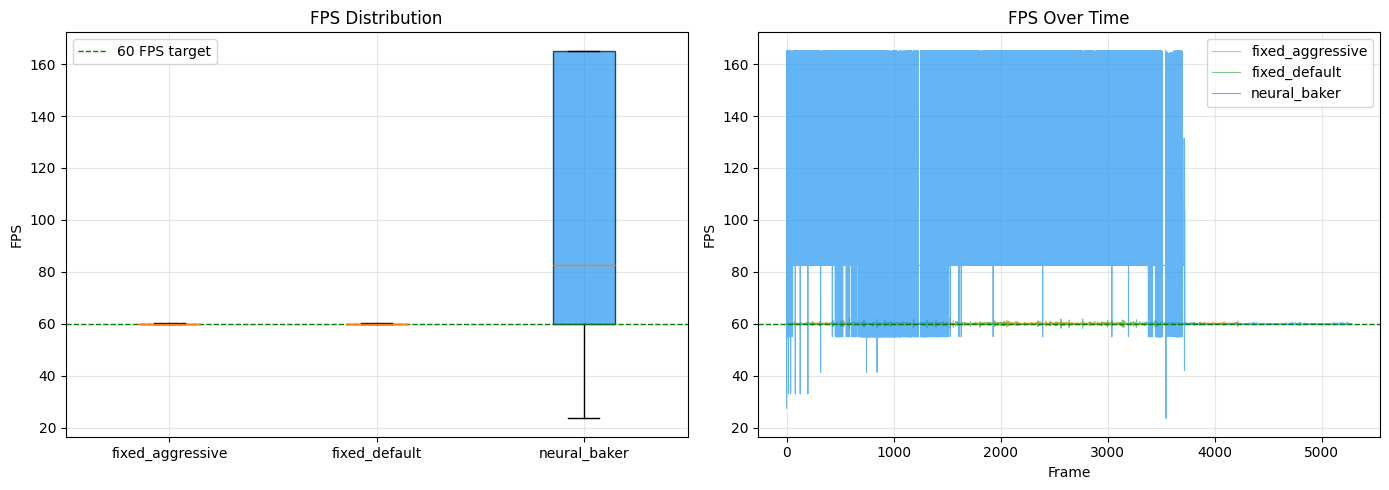

Saved: eval_fps_comparison.png


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
fps_data = [data[data['run_label'] == r]['fps'].dropna().values for r in runs]
bp = ax.boxplot(fps_data, labels=runs, patch_artist=True, showfliers=False)
for patch, run in zip(bp['boxes'], runs):
    patch.set_facecolor(RUN_COLORS.get(run, DEFAULT_COLOR))
    patch.set_alpha(0.7)
ax.axhline(60, color='green', linestyle='--', linewidth=1, label='60 FPS target')
ax.set_title('FPS Distribution')
ax.set_ylabel('FPS')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
# FPS over time per run
for run in runs:
    df = data[data['run_label'] == run].reset_index(drop=True)
    ax.plot(df.index, df['fps'], alpha=0.7, linewidth=0.8,
            color=RUN_COLORS.get(run, DEFAULT_COLOR), label=run)
ax.axhline(60, color='green', linestyle='--', linewidth=1)
ax.set_title('FPS Over Time')
ax.set_xlabel('Frame')
ax.set_ylabel('FPS')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eval_fps_comparison.png', dpi=150)
plt.show()
print('Saved: eval_fps_comparison.png')

## 7. Neural Baker — Inference Overhead

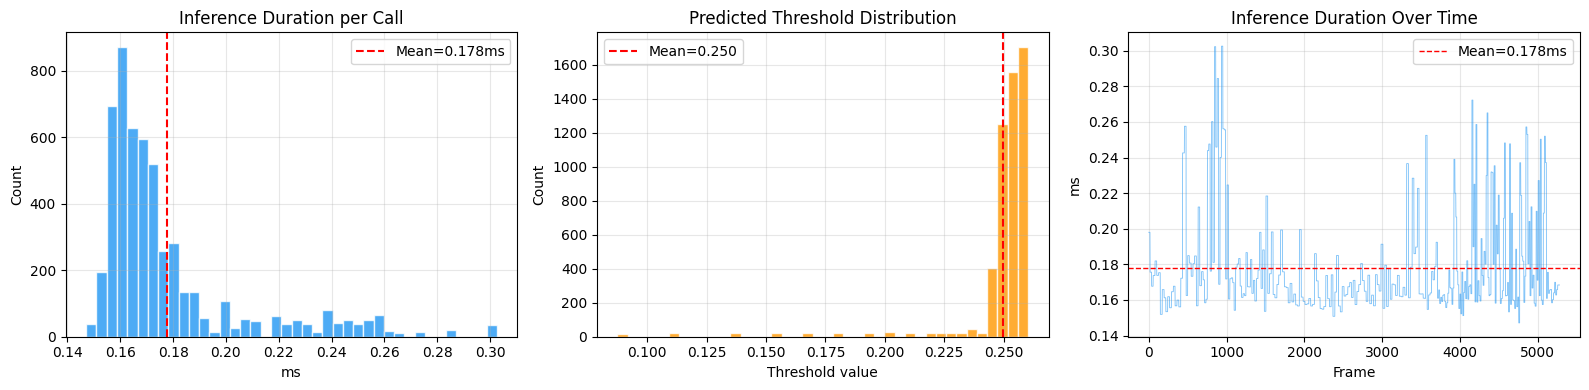

Inference overhead stats:
  Mean:  0.1778 ms
  P95:   0.2477 ms
  P99:   0.2844 ms
  Max:   0.3026 ms
  Saved: eval_inference_overhead.png


In [56]:
neural_df = data[data['run_label'] == 'neural_baker']

if len(neural_df) == 0:
    print('No neural_baker run found — skipping inference overhead analysis')
else:
    inf_ms = neural_df['inference_duration_ms'].dropna()
    thr    = neural_df['predicted_threshold'].dropna()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # inference duration histogram
    ax = axes[0]
    ax.hist(inf_ms, bins=40, color='#2196F3', alpha=0.8, edgecolor='white')
    ax.axvline(inf_ms.mean(), color='red', linestyle='--', label=f'Mean={inf_ms.mean():.3f}ms')
    ax.set_title('Inference Duration per Call')
    ax.set_xlabel('ms')
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # predicted threshold distribution
    ax = axes[1]
    ax.hist(thr, bins=40, color='#FF9800', alpha=0.8, edgecolor='white')
    ax.axvline(thr.mean(), color='red', linestyle='--', label=f'Mean={thr.mean():.3f}')
    ax.set_title('Predicted Threshold Distribution')
    ax.set_xlabel('Threshold value')
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # inference duration over time
    ax = axes[2]
    ax.plot(neural_df.index, inf_ms.values, alpha=0.6, linewidth=0.6, color='#2196F3')
    ax.axhline(inf_ms.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean={inf_ms.mean():.3f}ms')
    ax.set_title('Inference Duration Over Time')
    ax.set_xlabel('Frame')
    ax.set_ylabel('ms')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'eval_inference_overhead.png', dpi=150)
    plt.show()

    print(f'Inference overhead stats:')
    print(f'  Mean:  {inf_ms.mean():.4f} ms')
    print(f'  P95:   {np.percentile(inf_ms, 95):.4f} ms')
    print(f'  P99:   {np.percentile(inf_ms, 99):.4f} ms')
    print(f'  Max:   {inf_ms.max():.4f} ms')
    print(f'  Saved: eval_inference_overhead.png')

## 8. Predicted Threshold vs CPU/GPU Cost

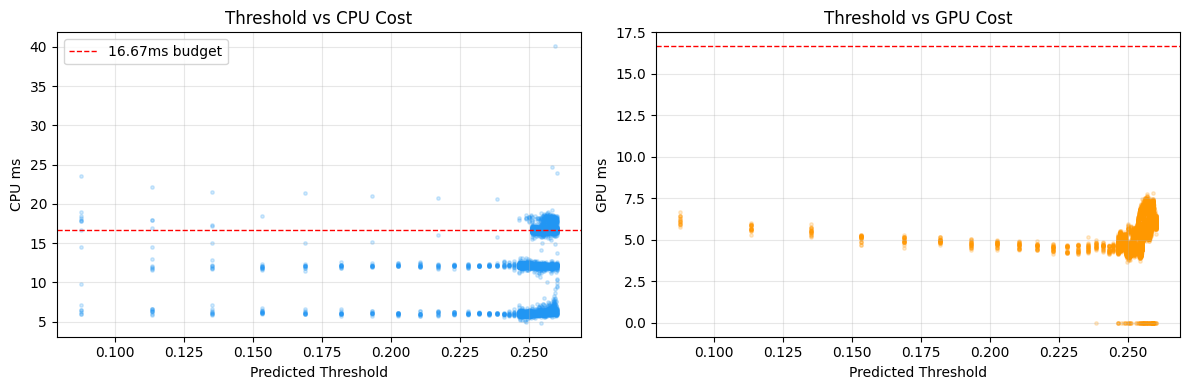

Saved: eval_threshold_vs_cost.png


In [57]:
neural_df = data[data['run_label'] == 'neural_baker'].copy()

if len(neural_df) == 0:
    print('No neural_baker run — skipping threshold correlation plot')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    ax.scatter(neural_df['predicted_threshold'], neural_df['cpu_ms'],
               alpha=0.2, s=6, c='#2196F3')
    ax.axhline(FRAME_BUDGET_MS, color='red', linestyle='--', linewidth=1, label=f'{FRAME_BUDGET_MS}ms budget')
    ax.set_xlabel('Predicted Threshold')
    ax.set_ylabel('CPU ms')
    ax.set_title('Threshold vs CPU Cost')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.scatter(neural_df['predicted_threshold'], neural_df['gpu_ms'],
               alpha=0.2, s=6, c='#FF9800')
    ax.axhline(FRAME_BUDGET_MS, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted Threshold')
    ax.set_ylabel('GPU ms')
    ax.set_title('Threshold vs GPU Cost')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'eval_threshold_vs_cost.png', dpi=150)
    plt.show()
    print('Saved: eval_threshold_vs_cost.png')

## 9. Frames Over Budget

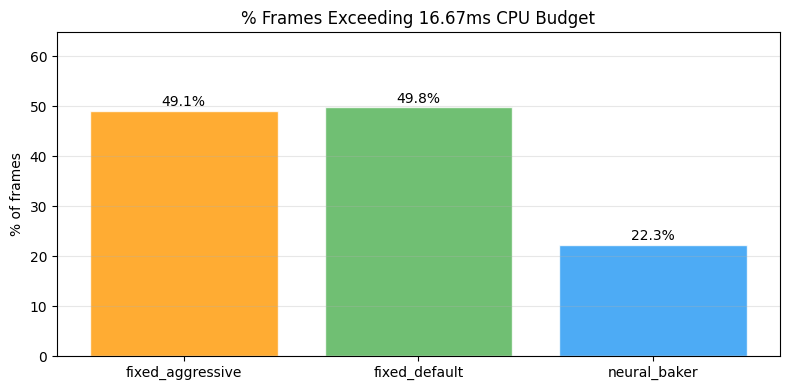

Saved: eval_over_budget.png


In [58]:
fig, ax = plt.subplots(figsize=(8, 4))

over_pcts = [summary.loc[r, 'over_budget_pct'] for r in runs]
colors = [RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs]
bars = ax.bar(runs, over_pcts, color=colors, alpha=0.8, edgecolor='white')

for bar, pct in zip(bars, over_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_title(f'% Frames Exceeding {FRAME_BUDGET_MS}ms CPU Budget')
ax.set_ylabel('% of frames')
ax.set_ylim(0, max(over_pcts) * 1.2 + 5)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eval_over_budget.png', dpi=150)
plt.show()
print('Saved: eval_over_budget.png')

## 10. Final Report Table

In [59]:
report_cols = [
    'frames', 'mean_cpu_ms', 'p95_cpu_ms', 'p99_cpu_ms',
    'mean_gpu_ms', 'p95_gpu_ms', 'mean_fps', 'p5_fps',
    'mean_inference_ms', 'mean_threshold',
    'lod_switches', 'flip_rate_per_s', 'over_budget_pct'
]

report = summary[report_cols]
print('=== Final Evaluation Report ===')
print(report.T.to_string())

# save to CSV
report.to_csv('eval_summary_report.csv')
print('\nSaved: eval_summary_report.csv')

# neural vs fixed_default delta if both exist
if 'neural_baker' in runs and 'fixed_default' in runs:
    print('\n=== Neural Baker vs Fixed Default ===')
    for metric in ['mean_cpu_ms','mean_gpu_ms','mean_fps','over_budget_pct']:
        n = summary.loc['neural_baker', metric]
        f = summary.loc['fixed_default', metric]
        delta = n - f
        pct   = 100 * delta / f if f != 0 else 0
        direction = 'higher' if delta > 0 else 'lower'
        print(f'  {metric}: neural={n:.3f} fixed={f:.3f} delta={delta:+.3f} ({pct:+.1f}% {direction})')

=== Final Evaluation Report ===
run_label          fixed_aggressive  fixed_default  neural_baker
frames                     4225.000       3914.000     5280.0000
mean_cpu_ms                  16.666         16.666       11.9650
p95_cpu_ms                   17.032         17.048       17.8230
p99_cpu_ms                   17.250         17.390       18.3740
mean_gpu_ms                   4.683          5.218        5.3060
p95_gpu_ms                    5.657          6.402        7.0550
mean_fps                     60.000         60.000      100.8800
p5_fps                       59.740         59.730       55.0000
mean_inference_ms             0.000          0.000        0.1778
mean_threshold                0.000          0.000        0.2497
lod_switches                  0.000          0.000        0.0000
flip_rate_per_s               0.000          0.000        0.0000
over_budget_pct              49.100         49.800       22.3000

Saved: eval_summary_report.csv

=== Neural Baker vs Fixed

## 11. Baseline Comparison Conclusion
Visualizes the performance differences across Neural Baker and static baselines.

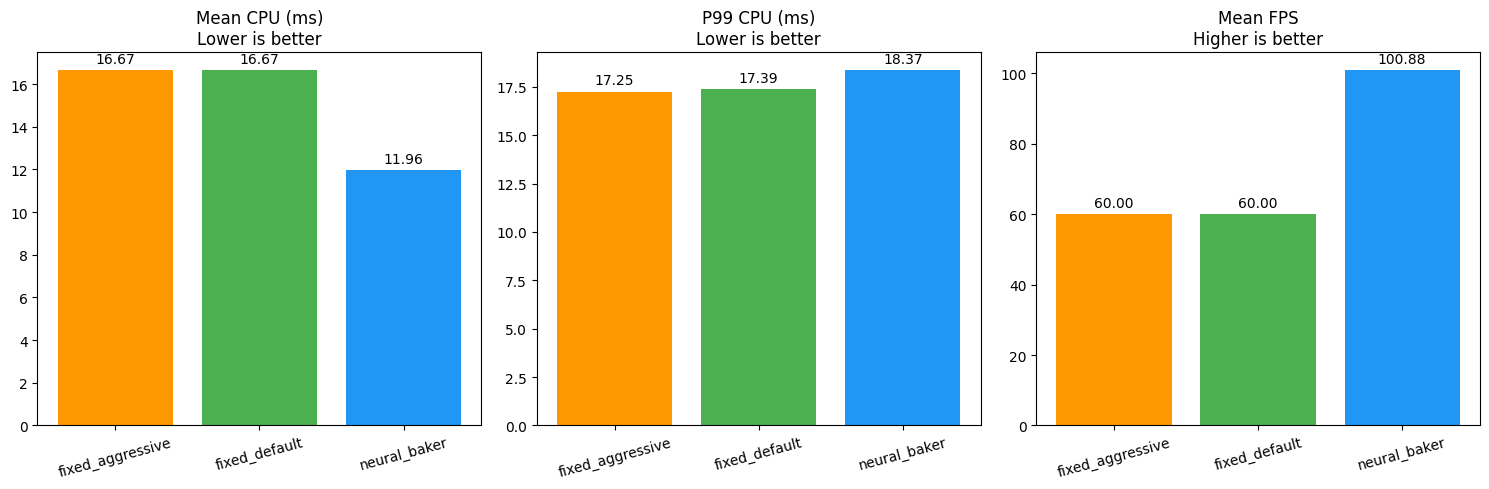

--------------------------------------------------
### Conclusion: Neural vs Baselines
Against Fixed Default:
- Mean CPU Time: Improved by 4.70 ms
- P99 CPU Time (Stutter): Worsened by 0.98 ms
- Average FPS: Increased by 40.88 FPS

Against Fixed Aggressive:
- Mean CPU Difference: Trailing by 4.70 ms


In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['mean_cpu_ms', 'p99_cpu_ms', 'mean_fps']
titles = ['Mean CPU (ms)\nLower is better', 'P99 CPU (ms)\nLower is better', 'Mean FPS\nHigher is better']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[i]
    vals = [summary.loc[r, metric] for r in runs if r in summary.index]
    active_runs = [r for r in runs if r in summary.index]
    
    bars = ax.bar(active_runs, vals, color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in active_runs])
    ax.set_title(title)
    ax.set_xticklabels(active_runs, rotation=15)
    
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'baseline_comparison.png', dpi=150)
plt.show()

print("--------------------------------------------------")
print("### Conclusion: Neural vs Baselines")
if 'neural_baker' in summary.index and 'fixed_default' in summary.index:
    cpu_delta = summary.loc['fixed_default', 'mean_cpu_ms'] - summary.loc['neural_baker', 'mean_cpu_ms']
    p99_delta = summary.loc['fixed_default', 'p99_cpu_ms'] - summary.loc['neural_baker', 'p99_cpu_ms']
    fps_delta = summary.loc['neural_baker', 'mean_fps'] - summary.loc['fixed_default', 'mean_fps']
    print(f"Against Fixed Default:")
    print(f"- Mean CPU Time: {'Improved' if cpu_delta > 0 else 'Worsened'} by {abs(cpu_delta):.2f} ms")
    print(f"- P99 CPU Time (Stutter): {'Improved' if p99_delta > 0 else 'Worsened'} by {abs(p99_delta):.2f} ms")
    print(f"- Average FPS: {'Increased' if fps_delta > 0 else 'Decreased'} by {abs(fps_delta):.2f} FPS")

if 'neural_baker' in summary.index and 'fixed_aggressive' in summary.index:
    cpu_opt = summary.loc['fixed_aggressive', 'mean_cpu_ms'] - summary.loc['neural_baker', 'mean_cpu_ms']
    print(f"\nAgainst Fixed Aggressive:")
    print(f"- Mean CPU Difference: {'Slightly ahead' if cpu_opt < 0 else 'Trailing'} by {abs(cpu_opt):.2f} ms")